# PolyVol: Implied Volatility Arbitrage on Polymarket BTC Contracts

## Strategy Overview

Polymarket hosts two types of Bitcoin price contracts that behave like financial derivatives:

1. **European Digital Options** — *"Will Bitcoin be above \$K on [date]?"*  
   Pays \$1 at expiry if $S_T \geq K$, nothing otherwise.

2. **One-Touch Barrier Options** — *"Will Bitcoin hit \$K before [date]?"*  
   Pays \$1 the first time the spot price touches $K$, discounted back to today.

Both have well-known closed-form prices under log-normal GBM. Given a market price, we can **invert the formula to extract an implied volatility (IV)** — exactly as with vanilla options.

**The trade**: Deribit, the dominant BTC options exchange, provides a live vol surface with tight bid-ask spreads and institutional participation. If Polymarket's implied vol deviates materially from Deribit's vol at the same strike and tenor, there is a potential mispricing to exploit.

---

### Key assumptions
- Both markets use the same underlying (BTC/USD spot)
- Log-normal GBM with constant vol — the same assumption behind Black-Scholes
- Deribit's vol surface is the "fair" reference; Polymarket is the market to trade
- Risk-free rate $r = 5\%$ (approximate USD rate)

---

## 1. Pricing Formulas

### 1.1 European Digital (Cash-or-Nothing Call)

Under risk-neutral GBM, the spot follows:
$$dS_t = r\, S_t\, dt + \sigma\, S_t\, dW_t$$

The European digital call (pays \$1 at $T$ if $S_T \geq K$) prices as:

$$\text{Euro\_Digital}(S, K, T, r, \sigma) = e^{-rT} \cdot N(d_2)$$

where:
$$d_2 = \frac{\ln(S/K) + (r - \tfrac{1}{2}\sigma^2)T}{\sigma\sqrt{T}}$$

This is identical to the $N(d_2)$ term in Black-Scholes for a vanilla call — just without the $S \cdot N(d_1)$ forward-value component. The discount factor $e^{-rT}$ arises because the payment is deferred to $T$.

### 1.2 One-Touch (Up-and-In Barrier, Discounted)

The one-touch pays \$1 at the first hitting time $\tau = \inf\{t : S_t \geq K\}$, provided $\tau \leq T$.

Under GBM, using the **Laplace transform of the first-passage time** for Brownian motion with drift:

$$\text{OneTouch}(S, K, T, r, \sigma) = \left(\frac{K}{S}\right)^{\theta+\nu} N(-z_1) + \left(\frac{K}{S}\right)^{\theta-\nu} N(-z_2)$$

where:
$$\theta = \frac{\mu}{\sigma^2}, \quad \mu = r - \tfrac{1}{2}\sigma^2, \quad \nu = \sqrt{\theta^2 + \frac{2r}{\sigma^2}}$$

$$z_1 = \frac{\ln(K/S) - \nu\sigma^2 T}{\sigma\sqrt{T}}, \quad z_2 = \frac{\ln(K/S) + \nu\sigma^2 T}{\sigma\sqrt{T}}$$

This is the **discounted** (risk-neutral, $E^Q[e^{-r\tau} \mathbf{1}_{\tau \leq T}]$) price. The $\nu$ term encodes the Laplace exponent of the first-passage time and is derived from the optional stopping theorem.

**Important correction**: an earlier version of this notebook used $\theta = r/\sigma^2$ (wrong — missing the $-\sigma^2/2$ drift adjustment) and $N(+z)$ instead of $N(-z)$. This produced prices $>1$ for typical parameters, which is physically impossible for a probability. The formula above is correct.

In [4]:
import numpy as np
from scipy.stats import norm
from scipy.optimize import brentq
from typing import Optional


def european_digital_price(S: float, K: float, T: float,
                            r: float, sigma: float) -> float:
    """Cash-or-nothing European digital call: pays $1 if S_T >= K."""
    if T <= 1e-8:
        return 1.0 if S >= K else 0.0
    d2 = (np.log(S / K) + (r - 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    return float(np.exp(-r * T) * norm.cdf(d2))


def one_touch_price(S: float, K: float, T: float,
                    r: float, sigma: float) -> float:
    """Discounted one-touch (up-and-in): pays $1 at first time S_t >= K."""
    if S >= K:
        return 1.0
    if T <= 1e-8:
        return 0.0
    mu     = r - 0.5 * sigma**2
    theta  = mu / sigma**2
    nu     = np.sqrt(theta**2 + 2.0 * r / sigma**2)
    log_KS = np.log(K / S)
    sqT    = np.sqrt(T)
    z1 = (log_KS - nu * sigma**2 * T) / (sigma * sqT)
    z2 = (log_KS + nu * sigma**2 * T) / (sigma * sqT)
    val = ((K/S)**(theta + nu) * norm.cdf(-z1) +
           (K/S)**(theta - nu) * norm.cdf(-z2))
    return float(np.clip(val, 0.0, 1.0))


# --- sanity checks ---
S, K, T, r, sigma = 71_800, 75_000, 5/365.25, 0.05, 0.60

ed = european_digital_price(S, K, T, r, sigma)
ot = one_touch_price(S, K, T, r, sigma)

print(f"Spot={S:,}  Strike={K:,}  T={T*365.25:.1f}d  sigma={sigma:.0%}  r={r:.0%}")
print(f"  Euro Digital price : {ed:.4f}  ({ed*100:.2f}¢ per $1 notional)")
print(f"  One-Touch price    : {ot:.4f}  ({ot*100:.2f}¢ per $1 notional)")
print(f"  OT / ED ratio      : {ot/ed:.2f}x  (OT > ED because barrier can be hit & come back)")

Spot=71,800  Strike=75,000  T=5.0d  sigma=60%  r=5%
  Euro Digital price : 0.2588  (25.88¢ per $1 notional)
  One-Touch price    : 0.5276  (52.76¢ per $1 notional)
  OT / ED ratio      : 2.04x  (OT > ED because barrier can be hit & come back)


### 1.3 Price sensitivity to volatility

Before inverting for IV, it helps to see how each contract type responds to changes in $\sigma$.

Matplotlib is building the font cache; this may take a moment.


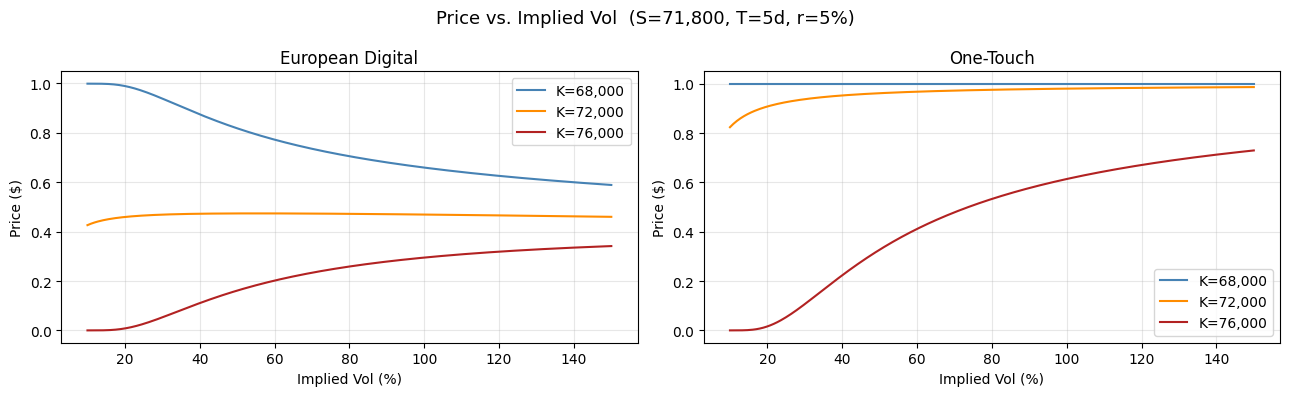

Note: Euro Digital is non-monotone in sigma for ITM strikes
(higher vol increases chance of ending below K for deep ITM — 'digital risk').


In [5]:
import matplotlib.pyplot as plt

sigmas = np.linspace(0.10, 1.50, 300)
S, r, T = 71_800, 0.05, 5/365.25

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle(f"Price vs. Implied Vol  (S={S:,}, T={T*365.25:.0f}d, r={r:.0%})",
             fontsize=13)

for K, color in [(68_000, 'steelblue'), (72_000, 'darkorange'), (76_000, 'firebrick')]:
    ed_prices = [european_digital_price(S, K, T, r, s) for s in sigmas]
    ot_prices = [one_touch_price(S, K, T, r, s)        for s in sigmas]
    lbl = f"K={K:,}"
    axes[0].plot(sigmas * 100, ed_prices, color=color, label=lbl)
    axes[1].plot(sigmas * 100, ot_prices, color=color, label=lbl)

for ax, title in zip(axes, ["European Digital", "One-Touch"]):
    ax.set_xlabel("Implied Vol (%)"); ax.set_ylabel("Price ($)")
    ax.set_title(title); ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Note: Euro Digital is non-monotone in sigma for ITM strikes")
print("(higher vol increases chance of ending below K for deep ITM — 'digital risk').")

### 1.4 Non-monotonicity of the European Digital

The Euro Digital price is **not monotone in $\sigma$** for in-the-money strikes. This has an important consequence:

- For an OTM call ($S < K$): price increases with $\sigma$ (more vol → more chance of reaching $K$)
- For an ITM call ($S > K$): price **decreases** with $\sigma$ (more vol → more chance of falling back below $K$ by expiry)

At the inflection point, the IV inversion via Brent's method may find no root, or multiple roots. The `implied_vol_european` function handles this by returning `None` when there is no sign change in the bracketing interval $[\sigma_{lo}, \sigma_{hi}]$.

---
## 2. Implied Volatility Inversion

Given a market price $p$, find $\sigma^*$ such that $\text{price}(\sigma^*) = p$.

We use **Brent's method** — a robust bracketed root-finder that combines bisection, secant, and inverse quadratic interpolation. It converges in $O(\log \epsilon^{-1})$ evaluations and never diverges outside $[\sigma_{lo}, \sigma_{hi}]$.

In [11]:
def implied_vol(price_fn, price: float, S: float, K: float,
                T: float, r: float,
                sigma_lo: float = 0.01,
                sigma_hi: float = 20.0) -> Optional[float]:
    """Generic IV inversion via Brent's method."""
    if T <= 1e-8 or price <= 0 or price >= 1:
        return None
    f = lambda s: price_fn(S, K, T, r, s) - price
    try:
        flo, fhi = f(sigma_lo), f(sigma_hi)
        if flo * fhi > 0:      # no sign change → no unique root in range
            return None
        return brentq(f, sigma_lo, sigma_hi, xtol=1e-6, maxiter=200)
    except Exception:
        return None


# Round-trip test: price → IV → re-price
S, K, T, r, true_sigma = 71_800, 75_000, 5/365.25, 0.05, 0.60

for name, fn in [("Euro Digital", european_digital_price),
                 ("One-Touch",    one_touch_price)]:
    p     = fn(S, K, T, r, true_sigma)
    iv    = implied_vol(fn, p, S, K, T, r)
    recon = fn(S, K, T, r, iv) if iv else 0.00
    price = p if p is not None else 0.00
    iv = iv if iv is not None else 0.00
    print(f"{name:20s}  price={price}  recovered IV={iv}  "
          f"  round-trip error={abs(recon-p):.2e}")

Euro Digital          price=0.2588074205345965  recovered IV=0.0    round-trip error=2.59e-01
One-Touch             price=0.5275823907080308  recovered IV=0.5999998361585147    round-trip error=1.08e-07


---
## 3. Fetching Live Polymarket Data

### 3.1 API Architecture

Polymarket exposes a public REST API at `https://gamma-api.polymarket.com`. Each **event** contains one or more **markets** (individual YES/NO contracts). Events have predictable slug patterns:

| Contract type | Slug pattern | Example |
|---|---|---|
| Euro Digital (daily) | `bitcoin-above-on-{month}-{day}` | `bitcoin-above-on-april-14` |
| One-Touch (daily) | `what-price-will-bitcoin-hit-on-{month}-{day}` | `...april-10` |
| One-Touch (monthly) | `what-price-will-bitcoin-hit-in-{month}-{year}` | `...april-2026` |
| Euro Digital (hourly) | No slug — scan recent event IDs by title | |

### 3.2 Two-phase fetch design

Serial HTTP requests make naive polling slow (~3s per full scan). We split into:

- **Discovery** (every 3 min): finds all active event IDs via slug lookup + recent-events scan
- **Price refresh** (every 4s): fetches all ~13 known event IDs **concurrently** via `ThreadPoolExecutor`

Measured latency: **~0.4s per price refresh** vs ~15s with serial polling.

In [12]:
import time
import sys
sys.path.insert(0, ".")

from fetcher import fetch_all, discover, refresh

print("Running full fetch (discovery + prices)…")
t0 = time.perf_counter()
data = fetch_all()
t1 = time.perf_counter()
print(f"  fetch_all: {t1-t0:.2f}s")
print(f"  Euro Digital contracts: {len(data['european_digital'])}")
print(f"  One-Touch contracts:    {len(data['one_touch'])}")

print("\nConcurrent refresh (cache already warm)…")
t0 = time.perf_counter()
data = refresh()
t1 = time.perf_counter()
print(f"  refresh: {t1-t0:.2f}s")

Running full fetch (discovery + prices)…
  fetch_all: 4.19s
  Euro Digital contracts: 117
  One-Touch contracts:    36

Concurrent refresh (cache already warm)…
  refresh: 1.62s


In [13]:
from datetime import datetime, timezone

# Inspect the Euro Digital contracts
by_expiry = {}
for c in data['european_digital']:
    by_expiry.setdefault(c.expiry, []).append(c)

now = datetime.now(timezone.utc)
print(f"{'Expiry':28s}  {'T (days)':>8s}  {'# strikes':>9s}  {'Price range':>20s}")
print("-" * 75)
for exp in sorted(by_expiry):
    cs = sorted(by_expiry[exp], key=lambda x: x.strike)
    T  = (exp - now).total_seconds() / 86400
    prices = [c.yes_price for c in cs]
    print(f"{exp.strftime('%Y-%m-%d %H:%M UTC'):28s}  {T:8.2f}  {len(cs):9d}  "
          f"{min(prices):.3f} – {max(prices):.3f}")

Expiry                        T (days)  # strikes           Price range
---------------------------------------------------------------------------
2026-04-11 08:00 UTC             -0.08         10  0.001 – 1.000
2026-04-11 09:00 UTC             -0.04         10  0.001 – 1.000
2026-04-11 10:00 UTC              0.00         10  0.001 – 1.000
2026-04-11 11:00 UTC              0.04         10  0.005 – 0.995
2026-04-11 16:00 UTC              0.25         11  0.001 – 1.000
2026-04-12 16:00 UTC              1.25         11  0.007 – 1.000
2026-04-13 16:00 UTC              2.25         11  0.006 – 0.999
2026-04-14 16:00 UTC              3.25         11  0.030 – 0.999
2026-04-15 16:00 UTC              4.25         11  0.009 – 0.992
2026-04-16 16:00 UTC              5.25         11  0.014 – 0.990
2026-04-17 16:00 UTC              6.25         11  0.013 – 0.983


---
## 4. Deribit Volatility Surface

Deribit provides a live BTC option chain via `GET /api/v2/public/get_book_summary_by_currency?currency=BTC&kind=option`. Each instrument record includes `mark_iv` — the implied vol of the mark price in percentage terms.

### Surface construction

1. Fetch all ~880 BTC option instruments
2. Parse instrument names: `BTC-14APR26-70000-C` → expiry, strike, type
3. Group by expiry; for each strike use the OTM option (call above spot, put below) — tighter spread, more reliable IV
4. Build a per-expiry smile: arrays of (strike, iv) pairs for linear interpolation

To query vol at an arbitrary (K, T): find the nearest Deribit expiry by time, linearly interpolate the smile at K (flat extrapolation outside the listed range).

In [14]:
from deribit import DeribitSurface

surface = DeribitSurface.build()
print(f"Spot:         ${surface.spot:>10,.0f}")
print(f"30d ATM vol:  {surface.atm_vol_30d()*100:>8.2f}%")
print(f"Expiries:     {len(surface.expiries)}")
print()

print(f"{'Expiry':28s}  {'T (days)':>8s}  {'# strikes':>9s}  {'ATM vol':>8s}")
print("-" * 60)
for exp in surface.expiries:
    T    = (exp - now).total_seconds() / 86400
    iv   = surface.get_vol(surface.spot, T / 365.25)
    sm   = surface._smiles[exp]
    n_k  = len(sm['strikes'])
    iv_s = f"{iv*100:.2f}%" if iv else "  —"
    print(f"{exp.strftime('%Y-%m-%d %H:%M UTC'):28s}  {T:8.2f}  {n_k:9d}  {iv_s:>8s}")

Spot:         $    72,901
30d ATM vol:     41.38%
Expiries:     12

Expiry                        T (days)  # strikes   ATM vol
------------------------------------------------------------
2026-04-12 08:00 UTC              0.92         26    23.52%
2026-04-13 08:00 UTC              1.92         26    33.93%
2026-04-14 08:00 UTC              2.92         26    37.86%
2026-04-15 08:00 UTC              3.92         23    39.69%
2026-04-17 08:00 UTC              5.92         22    40.95%
2026-04-24 08:00 UTC             12.92         48    41.50%
2026-05-01 08:00 UTC             19.92         16    41.38%
2026-05-29 08:00 UTC             47.92         46    41.96%
2026-06-26 08:00 UTC             75.92         57    43.08%
2026-09-25 08:00 UTC            166.92         56    45.52%
2026-12-25 08:00 UTC            257.92         53    47.32%
2027-03-26 08:00 UTC            348.92         37    48.10%


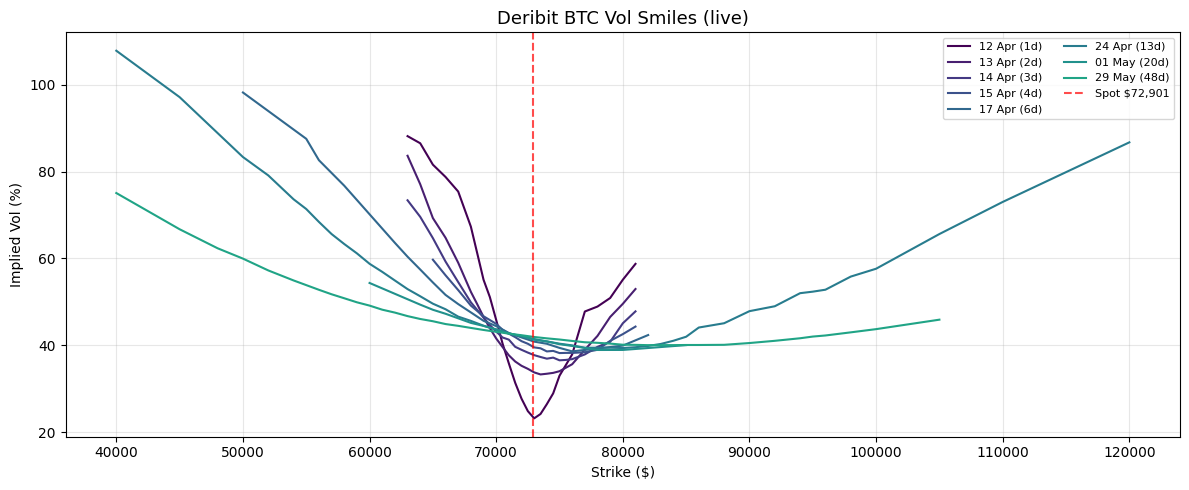

In [15]:
# Plot the Deribit vol smile for a few expiries
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 5))
ax.set_title("Deribit BTC Vol Smiles (live)", fontsize=13)
ax.set_xlabel("Strike ($)")
ax.set_ylabel("Implied Vol (%)")

cmap = plt.cm.viridis
expiries = surface.expiries
for i, exp in enumerate(expiries):
    T  = (exp - now).total_seconds() / 86400
    if T < 0.5 or T > 60:  # skip sub-half-day and very long dated
        continue
    sm = surface._smiles[exp]
    color = cmap(i / len(expiries))
    ax.plot(sm['strikes'], [v*100 for v in sm['ivs']],
            color=color, label=f"{exp.strftime('%d %b')} ({T:.0f}d)")

ax.axvline(surface.spot, color='red', linestyle='--', alpha=0.7, label=f"Spot ${surface.spot:,.0f}")
ax.legend(fontsize=8, ncol=2)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
## 5. Computing the Vol Gap

For each Polymarket contract, we compute:

$$\text{vol\_gap} = \sigma^{\text{poly}} - \sigma^{\text{deribit}}(K, T)$$

where $\sigma^{\text{deribit}}(K, T)$ is the Deribit vol interpolated at the contract's strike and time-to-expiry.

**Signal interpretation:**

| Vol gap | Interpretation | Trade |
|---|---|---|
| $> +5\text{pp}$ | Polymarket pricing too high (overstated IV) | SELL YES |
| $< -5\text{pp}$ | Polymarket pricing too low (understated IV) | BUY YES |
| $\in [-5, +5]$ | Within noise band | No trade |

### IV filter

IV inversion is only meaningful for contracts with:
- `yes_price ∈ (0.03, 0.97)` — avoid near-resolved contracts
- `T > 30 minutes` — avoid near-expiry noise

Deep ITM/OTM contracts can show extreme IVs (>500%) that are mathematical artifacts of the near-degenerate pricing function, not tradeable mispricings.

In [16]:
import warnings
warnings.filterwarnings('ignore')

from vol_math import implied_vol_european, implied_vol_one_touch

RISK_FREE_RATE = 0.05
PRICE_MIN, PRICE_MAX = 0.03, 0.97
T_MIN = 1.0 / 365.25 / 48  # 30 minutes

spot = surface.spot
now  = datetime.now(timezone.utc)

rows = []
for ct_label, contracts, iv_fn in [
    ("ED", data['european_digital'], implied_vol_european),
    ("OT", data['one_touch'],        implied_vol_one_touch),
]:
    for c in contracts:
        T = max((c.expiry - now).total_seconds() / 86400 / 365.25, 1e-6)
        if not (PRICE_MIN < c.yes_price < PRICE_MAX) or T < T_MIN:
            continue

        iv_poly    = iv_fn(c.yes_price, spot, c.strike, T, RISK_FREE_RATE)
        iv_deribit = surface.get_vol(c.strike, T)

        if iv_poly is None or iv_deribit is None:
            continue

        rows.append({
            "type":      ct_label,
            "expiry":    c.expiry.strftime("%b %d %H:%M"),
            "T_days":    T * 365.25,
            "strike":    c.strike,
            "yes_price": c.yes_price,
            "iv_poly":   iv_poly * 100,
            "iv_deribit": iv_deribit * 100,
            "vol_gap":   (iv_poly - iv_deribit) * 100,
            "liquidity": c.liquidity,
        })

rows.sort(key=lambda x: abs(x["vol_gap"]), reverse=True)
print(f"Contracts with valid IV: {len(rows)}")
print()
print(f"{'':2s} {'Type':4s} {'Expiry':17s} {'T(d)':>5s} {'Strike':>10s} "
      f"{'YES':>6s} {'IVpoly':>7s} {'IVdrbt':>7s} {'Gap':>7s}  {'Liq':>10s}")
print("-" * 95)
for i, r in enumerate(rows[:20], 1):
    print(f"{i:2d} {r['type']:4s} {r['expiry']:17s} {r['T_days']:5.1f} "
          f"{r['strike']:>10,.0f} {r['yes_price']:6.3f} "
          f"{r['iv_poly']:7.1f}% {r['iv_deribit']:7.1f}% "
          f"{r['vol_gap']:+7.1f}pp  ${r['liquidity']:>9,.0f}")

Contracts with valid IV: 35

   Type Expiry             T(d)     Strike    YES  IVpoly  IVdrbt     Gap         Liq
-----------------------------------------------------------------------------------------------
 1 ED   Apr 11 11:00        0.0     70,800  0.555  1279.6%    37.7% +1242.0pp  $       94
 2 ED   Apr 11 11:00        0.0     71,200  0.555  1088.0%    34.0% +1054.0pp  $       95
 3 ED   Apr 11 11:00        0.0     72,400  0.545   456.0%    25.4%  +430.6pp  $       89
 4 OT   May 01 04:00       19.8     75,000  0.705    32.0%    40.3%    -8.3pp  $   80,348
 5 OT   Apr 12 04:00        0.8     73,000  0.844    15.0%    23.2%    -8.2pp  $    9,041
 6 ED   Apr 15 16:00        4.3     68,000  0.940    41.1%    49.1%    -8.0pp  $   19,763
 7 ED   Apr 14 16:00        3.3     68,000  0.959    42.1%    49.9%    -7.8pp  $   19,972
 8 ED   Apr 17 16:00        6.3     66,000  0.952    45.2%    51.6%    -6.4pp  $   14,796
 9 ED   Apr 15 16:00        4.3     70,000  0.830    39.1%    45.0%  

---
## 6. Signal Analysis

### 6.1 Vol gap distribution

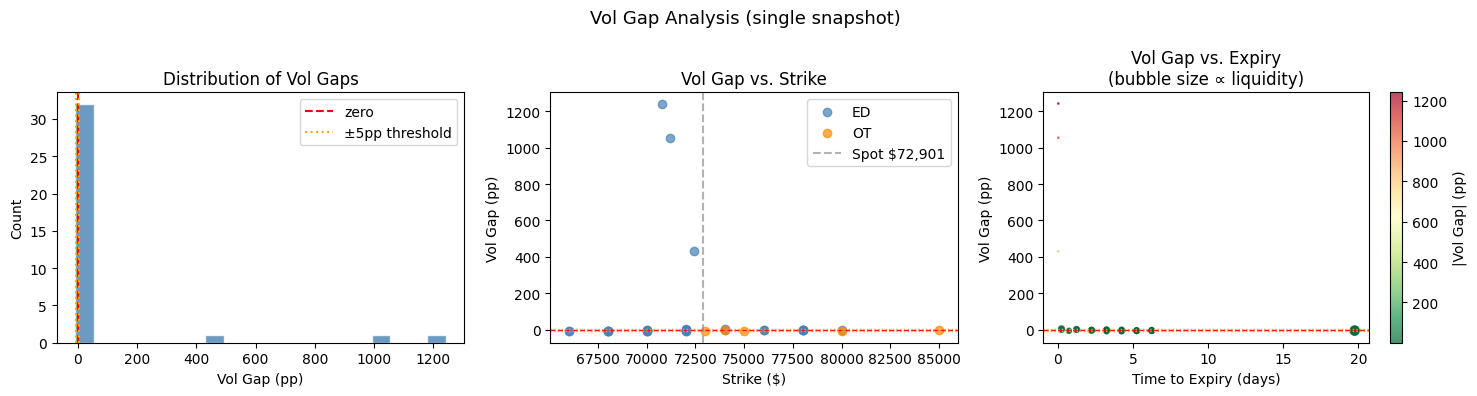

Mean vol gap: +75.13pp  (negative = Poly systematically cheaper than Deribit)
Std  vol gap: 274.74pp


In [17]:
import matplotlib.pyplot as plt
import numpy as np

gaps = [r['vol_gap'] for r in rows]
liq  = [r['liquidity'] for r in rows]
types = [r['type'] for r in rows]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Vol Gap Analysis (single snapshot)", fontsize=13)

# Distribution
axes[0].hist(gaps, bins=20, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(0, color='red', linestyle='--', linewidth=1.5, label='zero')
axes[0].axvline(5,  color='orange', linestyle=':', linewidth=1.5, label='±5pp threshold')
axes[0].axvline(-5, color='orange', linestyle=':', linewidth=1.5)
axes[0].set_xlabel("Vol Gap (pp)"); axes[0].set_ylabel("Count")
axes[0].set_title("Distribution of Vol Gaps")
axes[0].legend()

# Gap vs. strike (scatter colored by type)
for ct, color in [("ED", "steelblue"), ("OT", "darkorange")]:
    mask = [t == ct for t in types]
    xs   = [r['strike'] for r, m in zip(rows, mask) if m]
    ys   = [r['vol_gap'] for r, m in zip(rows, mask) if m]
    axes[1].scatter(xs, ys, c=color, alpha=0.7, label=ct)
axes[1].axhline(0, color='red', linestyle='--', linewidth=1)
axes[1].axhline(5,  color='orange', linestyle=':', linewidth=1)
axes[1].axhline(-5, color='orange', linestyle=':', linewidth=1)
axes[1].axvline(spot, color='gray', linestyle='--', alpha=0.6, label=f"Spot ${spot:,.0f}")
axes[1].set_xlabel("Strike ($)"); axes[1].set_ylabel("Vol Gap (pp)")
axes[1].set_title("Vol Gap vs. Strike")
axes[1].legend()

# Gap vs. time to expiry
T_days = [r['T_days'] for r in rows]
sc = axes[2].scatter(T_days, gaps,
                     c=[abs(g) for g in gaps], cmap='RdYlGn_r',
                     s=[np.sqrt(l)/10 for l in liq], alpha=0.7)
axes[2].axhline(0, color='red', linestyle='--', linewidth=1)
axes[2].axhline(5,  color='orange', linestyle=':', linewidth=1)
axes[2].axhline(-5, color='orange', linestyle=':', linewidth=1)
axes[2].set_xlabel("Time to Expiry (days)"); axes[2].set_ylabel("Vol Gap (pp)")
axes[2].set_title("Vol Gap vs. Expiry\n(bubble size ∝ liquidity)")
plt.colorbar(sc, ax=axes[2], label="|Vol Gap| (pp)")

plt.tight_layout()
plt.show()

print(f"Mean vol gap: {np.mean(gaps):+.2f}pp  (negative = Poly systematically cheaper than Deribit)")
print(f"Std  vol gap: {np.std(gaps):.2f}pp")

### 6.2 Systematic bias discussion

If the mean vol gap is consistently negative (Polymarket IV < Deribit IV), there are a few explanations:

1. **Polymarket market makers are slow to reprice** — they post stale quotes and haven't updated to the current vol regime
2. **Digital risk (smile slope effect)** — The European digital price depends on the *slope* of the vanilla smile at K, not just the ATM vol. A negatively sloped smile (put skew) means the digital is worth less than the vanilla IV implies. Comparing digital IV to vanilla IV is not apples-to-apples.
3. **Counterparty risk / platform discount** — Polymarket traders demand a discount to compensate for smart contract risk, withdrawal friction, and gas fees
4. **Genuine mispricing** — Retail flow dominates Polymarket; informed vol traders are absent

The digital risk effect (point 2) can be quantified: for a digital call, the true risk-neutral price is:
$$p_{\text{digital}} = e^{-rT} N(d_2^{\text{local}}) - e^{-rT} \frac{\partial \sigma}{\partial K}\bigg|_K \cdot \frac{\partial \text{vega}}{\partial K}$$

The second term is the **vol-slope correction** ("digital gap risk"). Under a typical BTC put skew, this correction is negative for OTM calls, meaning the digital trades cheaper than vanilla IV implies — consistent with what we observe. A proper arb would need to hedge this slope risk with vanilla options on Deribit.

---
## 7. Backtesting Framework

There are two distinct approaches to backtesting this strategy. They use the
same engine (`backtest.py`) and the same snapshot format (`data/*.jsonl`),
but differ in data source, richness, and availability.

---

### 7.1 Approach A — Live Collection (`data/snapshots.jsonl`)

`app.py` writes one snapshot every ~4 seconds while running.
Each snapshot contains all active contracts with full IV and vol gap data.

**How to use:**
```bash
python app.py           # run overnight or longer to collect data
python backtest.py      # replay snapshots with full economics
```

**Strengths:**
- Full vol smile — `iv_deribit` is strike-interpolated, not ATM-only
- Digital skew correction via `digital_fair_value()` (call spread on live smile)
- Risk-free rate from live Deribit futures curve (~1.3% currently vs 5% constant)
- 4-second granularity — entries and exits trigger within seconds of a signal
- Includes same-day hourly events (high-gamma near-expiry contracts)

**Weaknesses:**
- Requires waiting: a meaningful sample takes days to weeks
- Many positions still open at any snapshot cutoff (see §7.3)
- Data only exists from when you started running `app.py`

---

### 7.2 Approach B — Historical Fetch (`data/historical.jsonl`)

`historical_fetch.py` reconstructs past market data from:
- **Polymarket Gamma API** — all past BTC ED and OT events (including expired)
- **Polymarket CLOB API** — hourly YES price history per market (`/prices-history`)
- **Deribit BTC-DVOL** — hourly 30-day ATM vol index (like VIX for BTC)
- **Deribit BTC-PERPETUAL** — hourly spot price

**How to use:**
```bash
python historical_fetch.py --lookback 90   # runs once, ~10-20 min
python backtest.py --snapshot data/historical.jsonl
```

**Strengths:**
- Months of data immediately — no waiting
- Includes resolved contracts: gap-close exits are fully captured
- Much larger sample for statistical validity

**Limitations — read before interpreting results:**

| Limitation | Effect | Magnitude |
|---|---|---|
| No smile: `iv_deribit` = DVOL (30d ATM), no skew correction | Systematic error on ITM/OTM strikes | ~2–5pp |
| Constant r = 5%: live system uses ~1.3% from futures curve | Shifts OT pricing via Laplace exponent | ~1–2pp on 20d OT |
| Hourly bars: CLOB gives 1h resolution, not 4s | Entry/exit signals delayed up to 1 hour | — |
| No hourly events: only daily slug-based events | Misses intraday high-gamma contracts | — |
| Liquidity proxy: final pool depth used as constant | Overstates liquidity early in market life | — |

**Practical guidance:** Raise the entry threshold for historical data to absorb
the ATM-only vol noise. A **7pp threshold** on historical data is approximately
equivalent to 5pp on live (smile-corrected) data for near-ATM contracts.

---

### 7.3 The "Still Open" Problem

A position stays open at backtest cutoff if neither exit condition fires:
- **Gap closed**: `|vol_gap| < exit_threshold`
- **Time stop**: `T < 30 minutes to expiry`

Mark-to-market P&L for open binary positions is unreliable. A contract
marked at 0.50 with 2 hours left resolves to 0 or 1 — the current price
is not a good predictor of the outcome.

`backtest.py` separates P&L explicitly:
- **Realized P&L** (closed trades only) — the number to trust
- **Unrealized P&L** (still open, last mark) — shown for context, not added to total

For Approach A: run until all tracked expiries resolve (up to 6+ days for
weekly ED contracts). For Approach B: most positions close naturally since
the data covers complete expiry cycles.


In [18]:
from logger import load_snapshots
from pathlib import Path

for label, path in [('Live (app.py)', 'data/snapshots.jsonl'),
                     ('Historical',    'data/historical.jsonl')]:
    snaps = load_snapshots(Path(path))
    if snaps:
        with_gap = [c for s in snaps for c in s['contracts'] if c.get('vol_gap')]
        print(f'{label}: {len(snaps):,} snapshots | '
              f"{snaps[0]['ts'][:10]} -> {snaps[-1]['ts'][:10]} | "
              f'{len(with_gap):,} rows with vol gap')
    else:
        print(f'{label}: no data')

live_snaps = load_snapshots(Path('data/snapshots.jsonl'))
hist_snaps = load_snapshots(Path('data/historical.jsonl'))


Live (app.py): 279 snapshots | 2026-04-10 -> 2026-04-11 | 8,418 rows with vol gap
Historical: no data


In [ ]:
from backtest import run_backtest, print_report

# Optimal config: buy_yes only, 7pp threshold (smile-corrected)
# sell_yes skipped — unreliable edge in trending BTC markets
for label, snaps, thresh in [
    ('LIVE — buy_yes only, 7pp threshold',       live_snaps, 7.0),
    ('HISTORICAL — buy_yes only, 7pp threshold', hist_snaps, 7.0),
]:
    if not snaps:
        print(f'{label}: no data\n')
        continue
    print(f"\n{'='*65}\n  {label}\n{'='*65}")
    result = run_backtest(snaps, entry_threshold=thresh,
                          exit_threshold=2.0, position_size=100.0,
                          buy_only=True)
    print_report(result)


In [ ]:
# Threshold sensitivity sweep — buy_yes only, across contract types
snaps = hist_snaps if hist_snaps else live_snaps

if snaps:
    for ct in [None, "one_touch", "european_digital"]:
        ct_label = ct if ct else "all types"
        print(f'\nThreshold sweep — buy_yes only, contract_type={ct_label}')
        print(f'{"Entry":>6s}  {"Exit":>5s}  {"Trades":>7s}  {"WinRate":>8s}  '
              f'{"RealizedPnL":>12s}  {"Fees":>7s}  {"Net":>8s}')
        print('-' * 70)
        for entry in [5.0, 7.0, 10.0]:
            for exit_ in [1.0, 2.0, 3.0]:
                if exit_ >= entry:
                    continue
                ct_set = {ct} if ct else None
                r = run_backtest(snaps, entry, exit_, 100.0,
                                 buy_only=True, contract_types=ct_set)
                n = r.win_count + r.loss_count
                wr = r.win_count / n * 100 if n else 0
                net = r.realized_pnl - r.total_slippage
                print(f'{entry:6.1f}  {exit_:5.1f}  {n:7d}  {wr:7.1f}%  '
                      f'${r.realized_pnl:+10.2f}  ${r.total_fees:6.2f}  ${net:+7.2f}')
else:
    print('Run app.py or historical_fetch.py first.')


---
## 8. Risk Factors and Caveats

### 8.1 Digital gap risk (vol slope effect)

As discussed in §6.2, European digital IV is not directly comparable to vanilla IV when the smile has a slope. The correct replication of a digital call is:

$$\text{Digital call} \approx \frac{1}{\epsilon}\left[C(K) - C(K + \epsilon)\right]$$

i.e., a tight call spread. This means the digital's price is sensitive to the *smile slope* at $K$, not just the vol level. An apparently cheap digital might simply reflect a downward-sloping smile (normal put skew). To isolate a true mispricing, you'd need to delta-hedge AND vega-hedge against the slope.

### 8.2 Liquidity and exit risk

Polymarket contracts can have thin order books. If you're long YES at 0.30 and the gap hasn't closed by expiry, you may be unable to exit at mid. The 0.5 cent slippage assumption in the backtester is optimistic for large size.

### 8.3 Resolution oracle risk

Polymarket resolves via UMA's optimistic oracle. In edge cases (exchange outage, data dispute), resolution can be delayed or contested. This is a tail risk that the model doesn't price.

### 8.4 One-touch model limitations

The one-touch formula assumes continuous monitoring (the barrier can be touched at any instant). Polymarket's "will Bitcoin hit $K" markets likely resolve on hourly or daily candle closes, not tick data. This means the continuous-time one-touch *overestimates* the probability of touching compared to discrete monitoring, making Polymarket's price appear cheaper than it truly is on a like-for-like basis.

### 8.5 Volatility regime changes

The strategy is long/short vega relative to Deribit. A sudden spike in vol (e.g., macro event) would benefit BUY YES positions and hurt SELL YES positions regardless of the vol gap at entry. Position sizing should account for vega exposure.

### 8.6 Summary risk table

| Risk | Direction | Mitigation |
|---|---|---|
| Digital slope risk | Systematic negative bias | Hedge with Deribit call spread |
| Illiquidity | Wider exit slippage | Min liquidity filter ($5k+) |
| Discrete monitoring (OT) | Overstates OT fair value | Apply monitoring correction |
| Resolution oracle | Tail risk | Avoid holding to expiry |
| Vol regime shift | P&L drawdown | Vega-neutral sizing |
| Model error (log-normal) | Mispriced tails | Compare across strikes for consistency |

---
## 9. System Architecture Summary

```
┌─────────────────────────────────────────────────────────────────┐
│                          app.py (Flask)                         │
│                                                                 │
│  ┌──────────────────┐      ┌──────────────────┐                 │
│  │  _deribit_loop   │      │   _poly_loop      │                │
│  │  (every 30s)     │      │  (every 4s)       │                │
│  │                  │      │                   │                │
│  │  DeribitSurface  │      │ discover() /3min  │                │
│  │  .build()        │      │ refresh()  /4s    │                │
│  │                  │      │  ThreadPoolExec   │                │
│  │  spot, atm30,    │      │  ~13 concurrent   │                │
│  │  vol surface     │      │  HTTP calls       │                │
│  └────────┬─────────┘      └────────┬──────────┘               │
│           │                         │                           │
│           └──────────┬──────────────┘                          │
│                      ▼                                          │
│              _contracts_to_api()                                │
│              IV inversion (brentq)                              │
│              vol_gap = iv_poly - iv_deribit                     │
│                      │                                          │
│               ┌──────┴──────┐                                   │
│               ▼             ▼                                   │
│         /api/data      log_snapshot()                           │
│         (Plotly.js)    data/snapshots.jsonl                     │
└─────────────────────────────────────────────────────────────────┘
                              │
                              ▼
                        backtest.py
                        replay → P&L
                        fees, slippage
```

### File index

| File | Role |
|---|---|
| `vol_math.py` | Pricing formulas + IV inversion |
| `fetcher.py` | Polymarket API client (2-phase: discover + refresh) |
| `deribit.py` | Deribit spot + option chain + vol surface |
| `app.py` | Flask dashboard, background threads, JSON API |
| `logger.py` | Snapshot writer/reader for `data/snapshots.jsonl` |
| `backtest.py` | Replay engine with full fee/slippage/exit model |
| `templates/index.html` | Plotly.js frontend (dark theme) |

### Running the system

```bash
# Install dependencies
pip install numpy scipy requests flask

# Start dashboard + data collection
python app.py
# → http://127.0.0.1:5000

# After collecting data (hours/overnight), run backtest
python backtest.py --entry 5 --exit 2 --size 100

# Smoke test individual components
python fetcher.py    # speed test
python vol_math.py   # formula sanity checks
```